# Genome-Wide ATAC-seq Accessibility Analysis of Ohnolog Pairs
## *Cyprinus carpio* — Late Somite Stage

---

### Background

This notebook extends the regulatory characterisation of ohnolog pairs from Gibson (2024) by scaling the ATAC-seq accessibility analysis from a curated subset of 75 pairs to the full complement of 7,497 expressed ohnolog pairs (baseMean ≥ 150).

The original MSc analysis used semi-quantitative visual scoring of ATAC-seq tracks from the UCSC Genome Browser, anchored to the TSS-nearest PADRE within ±5kb. ATAC accessibility differences between subgenomes were non-significant across all expression bias categories in that curated set (q = 0.16–0.91). This analysis tests whether that finding holds at genome-wide scale using fully quantitative peak intersection.

### Biological Question

> To what extent does promoter-proximal chromatin accessibility asymmetry between ohnolog copies correlate with expression bias across the full 7,497-pair ohnolog complement at Late Somite stage?

### Data
- **Expression data**: DESeq2 L2FC and padj for 7,497 ohnolog pairs at Late Somite and Pre-Hatch, with CAJNDQ scaffold coordinates and Ensembl gene IDs
- **ATAC data**: Late Somite narrow peak BED file aligned to cypCar4 (WAG4.0); 126,877 peaks across 150 scaffolds
- **Gene coordinates**: Retrieved from Ensembl REST API using ENSCCRG identifiers

### Assembly
*Cyprinus carpio carpio* WAG4.0 / cypCar4 (NCBI: GCA_905221575.1)

---
## 0. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import pybedtools
import requests
import json
import os
import time
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display

# Plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print('All imports successful')

All imports successful


In [3]:
# ── USER PATHS — edit these if files are in different locations ──────────────
DEG_FILE   = os.path.expanduser('~/Desktop/DegListWithExNum_NEW.tsv')
PEAK_FILE  = os.path.expanduser('~/Desktop/LateSomATAC.narrowPeak')
OUT_DIR    = os.path.expanduser('~/Desktop/atac_analysis')
# ─────────────────────────────────────────────────────────────────────────────

PROMOTER_WINDOW  = 2000   # bp upstream and downstream of TSS
BATCH_SIZE       = 300    # Ensembl REST API max per POST
BASE_MEAN_CUTOFF = 150
PSEUDOCOUNT      = 0.1    # for log2 asymmetry calculation

os.makedirs(OUT_DIR, exist_ok=True)
print(f'Output directory: {OUT_DIR}')

Output directory: /Users/rossgibson/Desktop/atac_analysis


---
## 1. Load and Filter DEG List

The DEG list contains 9,581 ohnolog pairs. We apply the same baseMean ≥ 150 filter used in the MSc analysis to retain 7,497 pairs with sufficient expression for reliable differential analysis.

In [5]:
df = pd.read_excel(DEG_FILE, engine='openpyxl')
print(f'Total pairs loaded     : {len(df)}')
print(f'Columns                : {list(df.columns)}')

Total pairs loaded     : 9581
Columns                : ['geneID_sgA', 'geneID_sgB', 'geneName_sgA', 'geneName_sgB', 'exonCountA', 'exonCountB', 'chrom_sgA', 'chrom_sgB', 'baseMean', 'log2FoldChange_S11_Lsom', 'padj_S11_Lsom', 'log2FoldChange_S12_Prehatch', 'padj_S12_Prehatch']


In [7]:
df_filtered = df[df['baseMean'] >= BASE_MEAN_CUTOFF].copy().reset_index(drop=True)
print(f'After baseMean >= {BASE_MEAN_CUTOFF}: {len(df_filtered)} pairs')
display(df_filtered.head(3))

After baseMean >= 150: 7497 pairs


,geneID_sgA,geneID_sgB,geneName_sgA,geneName_sgB,exonCountA,exonCountB,chrom_sgA,chrom_sgB,baseMean,log2FoldChange_S11_Lsom,padj_S11_Lsom,log2FoldChange_S12_Prehatch,padj_S12_Prehatch
0,ENSCCRG00000056663,ENSCCRG00000082183,ipo11,ipo11,30,28,CAJNDQ010000018.1,CAJNDQ010000024.1,1046.543287,12.752973,1.338535e-25,8.170216,5.928117e-79
1,ENSCCRG00000000292,ENSCCRG00000063159,umps,umps,6,6,CAJNDQ010000042.1,CAJNDQ010000047.1,362.356807,12.433650,2.379069e-23,11.709460,1.030165e-20
2,ENSCCRG00000051127,ENSCCRG00000008120,glra4b,glra4b,11,10,CAJNDQ010000008.1,CAJNDQ010000016.1,185.648183,12.346856,2.918256e-21,10.326651,1.281281e-25


In [9]:
# Assign expression bias categories — Late Somite
def assign_bias(row, l2fc_col, padj_col):
    if pd.isna(row[padj_col]) or row[padj_col] >= 0.05:
        return 'Balanced'
    elif row[l2fc_col] >= 2.0:
        return 'SubgA_extreme'
    elif row[l2fc_col] >= 1.0:
        return 'SubgA_strong'
    elif row[l2fc_col] >= 0.58:
        return 'SubgA_moderate'
    elif row[l2fc_col] <= -2.0:
        return 'SubgB_extreme'
    elif row[l2fc_col] <= -1.0:
        return 'SubgB_strong'
    elif row[l2fc_col] <= -0.58:
        return 'SubgB_moderate'
    else:
        return 'Balanced'

df_filtered['bias_lsom'] = df_filtered.apply(
    lambda r: assign_bias(r, 'log2FoldChange_S11_Lsom', 'padj_S11_Lsom'), axis=1)
df_filtered['bias_phatch'] = df_filtered.apply(
    lambda r: assign_bias(r, 'log2FoldChange_S12_Prehatch', 'padj_S12_Prehatch'), axis=1)

print('Late Somite bias category distribution:')
display(df_filtered['bias_lsom'].value_counts().to_frame())

Late Somite bias category distribution:


,count
bias_lsom,
Balanced,3677
SubgB_strong,773
SubgA_strong,752
SubgB_extreme,666
SubgA_moderate,581
SubgB_moderate,530
SubgA_extreme,518


---
## 2. Retrieve TSS Coordinates from Ensembl REST API

Gene coordinates for all ENSCCRG Ensembl IDs are retrieved from the Ensembl REST API in batches of 300. Results are cached locally to avoid repeated API calls on re-runs.

**Note**: This step queries ~15,000 unique gene IDs and will take several minutes on first run. Subsequent runs load from cache instantly.

In [11]:
all_ids = list(set(
    df_filtered['geneID_sgA'].tolist() +
    df_filtered['geneID_sgB'].tolist()
))
print(f'Unique Ensembl gene IDs to resolve: {len(all_ids)}')

Unique Ensembl gene IDs to resolve: 14994


In [13]:
ENSEMBL_URL  = 'https://rest.ensembl.org/lookup/id'
HEADERS      = {'Content-Type': 'application/json', 'Accept': 'application/json'}
cache_file   = os.path.join(OUT_DIR, 'ensembl_coords_cache.json')

# Load cache if available
if os.path.exists(cache_file):
    with open(cache_file) as f:
        coord_map = json.load(f)
    print(f'Loaded {len(coord_map)} cached coordinates')
else:
    coord_map = {}
    print('No cache found — will query Ensembl API')

ids_to_fetch = [i for i in all_ids if i not in coord_map]
print(f'IDs to fetch from API: {len(ids_to_fetch)}')

No cache found — will query Ensembl API
IDs to fetch from API: 14994


In [15]:
failed_ids = []
total_batches = (len(ids_to_fetch) + BATCH_SIZE - 1) // BATCH_SIZE

for i, batch_start in enumerate(range(0, len(ids_to_fetch), BATCH_SIZE)):
    batch = ids_to_fetch[batch_start:batch_start + BATCH_SIZE]
    print(f'  Batch {i+1}/{total_batches} ({len(batch)} IDs)...', end=' ')
    try:
        response = requests.post(
            ENSEMBL_URL,
            headers=HEADERS,
            data=json.dumps({'ids': batch}),
            timeout=60
        )
        if response.status_code == 200:
            result = response.json()
            fetched = 0
            for gene_id, info in result.items():
                if info and isinstance(info, dict):
                    coord_map[gene_id] = {
                        'seq_region_name': info.get('seq_region_name'),
                        'start':           info.get('start'),
                        'end':             info.get('end'),
                        'strand':          info.get('strand'),
                    }
                    fetched += 1
                else:
                    failed_ids.append(gene_id)
            print(f'OK ({fetched} retrieved)')
        else:
            print(f'FAILED (HTTP {response.status_code})')
            failed_ids.extend(batch)
    except Exception as e:
        print(f'ERROR: {e}')
        failed_ids.extend(batch)
    time.sleep(0.5)

# Save updated cache
with open(cache_file, 'w') as f:
    json.dump(coord_map, f)

print(f'\nTotal coordinates cached : {len(coord_map)}')
print(f'Failed / not found       : {len(failed_ids)}')

  Batch 1/50 (300 IDs)... OK (300 retrieved)
  Batch 2/50 (300 IDs)... OK (300 retrieved)
  Batch 3/50 (300 IDs)... OK (300 retrieved)
  Batch 4/50 (300 IDs)... OK (300 retrieved)
  Batch 5/50 (300 IDs)... OK (300 retrieved)
  Batch 6/50 (300 IDs)... OK (300 retrieved)
  Batch 7/50 (300 IDs)... OK (300 retrieved)
  Batch 8/50 (300 IDs)... OK (300 retrieved)
  Batch 9/50 (300 IDs)... OK (300 retrieved)
  Batch 10/50 (300 IDs)... OK (300 retrieved)
  Batch 11/50 (300 IDs)... OK (300 retrieved)
  Batch 12/50 (300 IDs)... OK (300 retrieved)
  Batch 13/50 (300 IDs)... OK (300 retrieved)
  Batch 14/50 (300 IDs)... OK (300 retrieved)
  Batch 15/50 (300 IDs)... OK (300 retrieved)
  Batch 16/50 (300 IDs)... OK (300 retrieved)
  Batch 17/50 (300 IDs)... OK (300 retrieved)
  Batch 18/50 (300 IDs)... OK (300 retrieved)
  Batch 19/50 (300 IDs)... OK (300 retrieved)
  Batch 20/50 (300 IDs)... OK (300 retrieved)
  Batch 21/50 (300 IDs)... OK (300 retrieved)
  Batch 22/50 (300 IDs)... OK (300 retrieve

In [17]:
# Inspect a sample coordinate entry
sample_id = list(coord_map.keys())[0]
print(f'Sample entry ({sample_id}):')
print(json.dumps(coord_map[sample_id], indent=2))

Sample entry (ENSCCRG00000069476):
{
  "seq_region_name": "CAJNDQ010000023.1",
  "start": 495753,
  "end": 502426,
  "strand": -1
}


---
## 3. Build Promoter Window BED Files

For each ohnolog copy, a ±2kb window is defined around the TSS. TSS is defined as the `start` position for forward-strand genes (strand = 1) and the `end` position for reverse-strand genes (strand = -1).

Where the Ensembl `seq_region_name` does not use CAJNDQ format, the scaffold identifier from the DEG list is used as a fallback to ensure coordinate compatibility with the narrowPeak file.

In [19]:
def get_tss(info):
    return info['start'] if info['strand'] == 1 else info['end']

def make_bed_row(gene_id, chrom_from_deg, info, window):
    tss   = get_tss(info)
    start = max(0, tss - window)
    end   = tss + window
    chrom = info['seq_region_name']
    if not str(chrom).startswith('CAJNDQ') and str(chrom_from_deg).startswith('CAJNDQ'):
        chrom = chrom_from_deg
    return (chrom, start, end, gene_id)

rows_a, rows_b, skipped = [], [], 0

for _, row in df_filtered.iterrows():
    info_a = coord_map.get(row['geneID_sgA'])
    info_b = coord_map.get(row['geneID_sgB'])
    if info_a and info_a.get('start'):
        rows_a.append(make_bed_row(row['geneID_sgA'], row['chrom_sgA'], info_a, PROMOTER_WINDOW))
    else:
        skipped += 1
    if info_b and info_b.get('start'):
        rows_b.append(make_bed_row(row['geneID_sgB'], row['chrom_sgB'], info_b, PROMOTER_WINDOW))
    else:
        skipped += 1

print(f'SubgA promoter windows : {len(rows_a)}')
print(f'SubgB promoter windows : {len(rows_b)}')
print(f'Skipped (no coords)    : {skipped}')

SubgA promoter windows : 7497
SubgB promoter windows : 7497
Skipped (no coords)    : 0


In [21]:
def write_bed(rows, filepath):
    with open(filepath, 'w') as f:
        for chrom, start, end, gene_id in rows:
            f.write(f'{chrom}\t{start}\t{end}\t{gene_id}\n')

bed_a = os.path.join(OUT_DIR, 'promoters_SubgA.bed')
bed_b = os.path.join(OUT_DIR, 'promoters_SubgB.bed')
write_bed(rows_a, bed_a)
write_bed(rows_b, bed_b)
print(f'BED files written: {bed_a}')
print(f'                   {bed_b}')

BED files written: /Users/rossgibson/Desktop/atac_analysis/promoters_SubgA.bed
                   /Users/rossgibson/Desktop/atac_analysis/promoters_SubgB.bed


---
## 4. Intersect Promoter Windows with ATAC Narrow Peaks

Each promoter window BED file is intersected with the Late Somite ATAC narrowPeak file using pybedtools. A left-outer join is used so that promoters with no overlapping peak are retained with a score of zero.

Where multiple peaks overlap a promoter window, the maximum fold enrichment value is used as the accessibility score for that locus.

In [59]:
# Strip track header line from narrowPeak
peak_stripped = os.path.join(OUT_DIR, 'LateSomATAC_noheader.narrowPeak')
with open(PEAK_FILE) as fin, open(peak_stripped, 'w') as fout:
    for line in fin:
        if not line.startswith('track'):
            fout.write(line)

peaks  = pybedtools.BedTool(peak_stripped)
prom_a = pybedtools.BedTool(bed_a)
prom_b = pybedtools.BedTool(bed_b)

print('Intersecting SubgA promoters with ATAC peaks...')
isect_a = prom_a.intersect(peaks, loj=True, wa=True, wb=True)
print('Intersecting SubgB promoters with ATAC peaks...')
isect_b = prom_b.intersect(peaks, loj=True, wa=True, wb=True)
print('Intersection complete.')

Intersecting SubgA promoters with ATAC peaks...
Intersecting SubgB promoters with ATAC peaks...
Intersection complete.


In [67]:
# Re-run intersection to refresh the generators
isect_a = prom_a.intersect(peaks, loj=True, wa=True, wb=True)
isect_b = prom_b.intersect(peaks, loj=True, wa=True, wb=True)

# Re-parse with corrected column indices
df_ia = parse_intersection(isect_a)
df_ib = parse_intersection(isect_b)

# Aggregate — max fold enrichment per gene
atac_a = (df_ia.groupby('gene_id')
          .agg(atac_fold_enrich_sgA=('fold_enrich', 'max'),
               peak_count_sgA=('fold_enrich', lambda x: (x > 0).sum()))
          .reset_index().rename(columns={'gene_id': 'geneID_sgA'}))

atac_b = (df_ib.groupby('gene_id')
          .agg(atac_fold_enrich_sgB=('fold_enrich', 'max'),
               peak_count_sgB=('fold_enrich', lambda x: (x > 0).sum()))
          .reset_index().rename(columns={'gene_id': 'geneID_sgB'}))

n_a = (atac_a['atac_fold_enrich_sgA'] > 0).sum()
n_b = (atac_b['atac_fold_enrich_sgB'] > 0).sum()
print(f'SubgA loci with ATAC peak overlap: {n_a} / {len(atac_a)}')
print(f'SubgB loci with ATAC peak overlap: {n_b} / {len(atac_b)}')

SubgA loci with ATAC peak overlap: 6541 / 7497
SubgB loci with ATAC peak overlap: 6572 / 7497


---
## 5. Calculate ATAC Accessibility Asymmetry

Accessibility asymmetry is calculated as:

$$\text{ATAC asymmetry} = \log_2\left(\frac{\text{SubgA fold enrichment} + \varepsilon}{\text{SubgB fold enrichment} + \varepsilon}\right)$$

where $\varepsilon = 0.1$ is a pseudocount to handle zero values. Positive values indicate greater SubgA accessibility; negative values indicate greater SubgB accessibility. This metric is directly analogous to the L2FC expression bias metric (log2(SubgA/SubgB)).

In [69]:
df_merged = (df_filtered
             .merge(atac_a, on='geneID_sgA', how='left')
             .merge(atac_b, on='geneID_sgB', how='left'))

df_merged['atac_fold_enrich_sgA'] = df_merged['atac_fold_enrich_sgA'].fillna(0)
df_merged['atac_fold_enrich_sgB'] = df_merged['atac_fold_enrich_sgB'].fillna(0)

df_merged['atac_asymmetry'] = np.log2(
    (df_merged['atac_fold_enrich_sgA'] + PSEUDOCOUNT) /
    (df_merged['atac_fold_enrich_sgB'] + PSEUDOCOUNT)
)

print('ATAC asymmetry summary statistics:')
display(df_merged['atac_asymmetry'].describe().round(4).to_frame())

ATAC asymmetry summary statistics:


,atac_asymmetry
count,7497.0000
mean,-0.0488
std,2.8029
min,-8.3819
25%,-0.4947
50%,0.0000
75%,0.4286
max,8.1770


---
## 6. Statistical Analysis

### 6.1 Spearman Correlation: ATAC Asymmetry vs L2FC

In [71]:
results = []
for stage, l2fc_col, padj_col in [
    ('Late Somite', 'log2FoldChange_S11_Lsom',     'padj_S11_Lsom'),
    ('Pre-Hatch',   'log2FoldChange_S12_Prehatch', 'padj_S12_Prehatch')
]:
    sub = df_merged.dropna(subset=[l2fc_col, 'atac_asymmetry'])
    rho, p = stats.spearmanr(sub['atac_asymmetry'], sub[l2fc_col])
    results.append({'Stage': stage, 'Spearman rho': round(rho, 4),
                    'p-value': f'{p:.2e}', 'n': len(sub)})

display(pd.DataFrame(results))

,Stage,Spearman rho,p-value,n
0,Late Somite,0.1153,1.35e-23,7497
1,Pre-Hatch,0.1054,5.60e-20,7497


### 6.2 ATAC Asymmetry by Expression Bias Category

In [73]:
# Simplified bias grouping for statistical tests
df_merged['bias_simple'] = df_merged['bias_lsom'].map({
    'SubgA_extreme':  'SubgA_dominant',
    'SubgA_strong':   'SubgA_dominant',
    'SubgA_moderate': 'SubgA_dominant',
    'SubgB_extreme':  'SubgB_dominant',
    'SubgB_strong':   'SubgB_dominant',
    'SubgB_moderate': 'SubgB_dominant',
    'Balanced':       'Balanced'
})

summary = df_merged.groupby('bias_simple')['atac_asymmetry'].agg(
    n='count', mean='mean', median='median', std='std').round(4)
display(summary)

,n,mean,median,std
bias_simple,,,,
Balanced,3677,-0.0154,0.0000,2.6611
SubgA_dominant,1851,0.3050,0.0322,2.8568
SubgB_dominant,1969,-0.4435,-0.1071,2.9577


In [75]:
# Mann-Whitney U tests between bias categories
a_dom = df_merged[df_merged['bias_simple'] == 'SubgA_dominant']['atac_asymmetry'].dropna()
b_dom = df_merged[df_merged['bias_simple'] == 'SubgB_dominant']['atac_asymmetry'].dropna()
bal   = df_merged[df_merged['bias_simple'] == 'Balanced']['atac_asymmetry'].dropna()

mw_tests = []
for g1, g2, n1, n2 in [
    ('SubgA_dominant', 'SubgB_dominant', a_dom, b_dom),
    ('SubgA_dominant', 'Balanced',       a_dom, bal),
    ('SubgB_dominant', 'Balanced',       b_dom, bal),
]:
    U, p = stats.mannwhitneyu(n1, n2, alternative='two-sided')
    mw_tests.append({'Comparison': f'{g1} vs {g2}',
                     'U statistic': round(U, 0),
                     'p-value': f'{p:.4e}',
                     'n1': len(n1), 'n2': len(n2)})

display(pd.DataFrame(mw_tests))

,Comparison,U statistic,p-value,n1,n2
0,SubgA_dominant vs SubgB_dominant,2121460.0,1.6082e-18,1851,1969
1,SubgA_dominant vs Balanced,3633465.0,3.8804e-05,1851,3677
2,SubgB_dominant vs Balanced,3244664.0,1.2710e-10,1969,3677


---
## 7. Visualisations

### 7.1 ATAC Asymmetry vs L2FC — Scatter Plot (Late Somite)

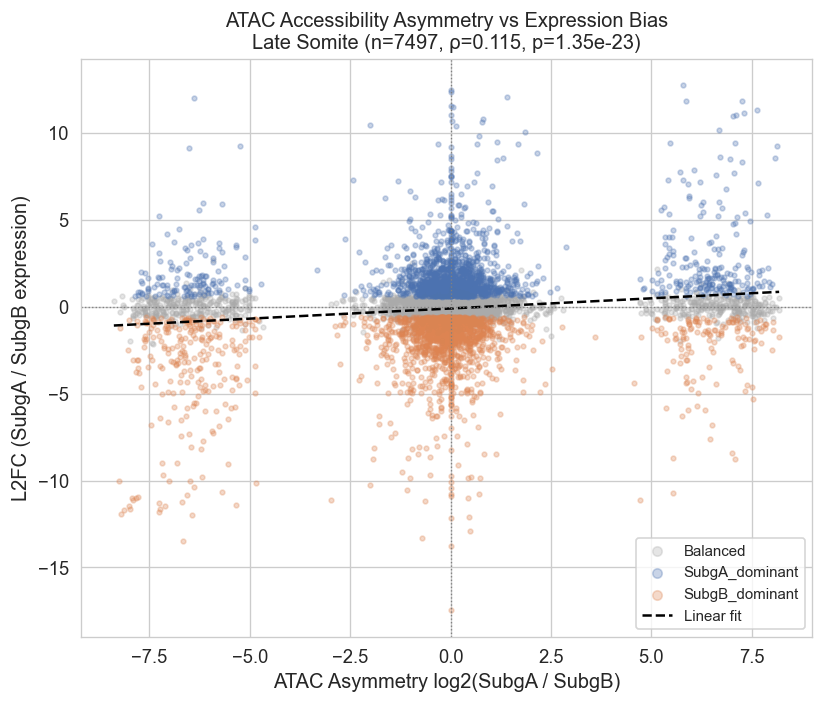

In [77]:
fig, ax = plt.subplots(figsize=(7, 6))

colours = {'SubgA_dominant': '#4C72B0', 'SubgB_dominant': '#DD8452', 'Balanced': '#aaaaaa'}
for bias, grp in df_merged.groupby('bias_simple'):
    ax.scatter(grp['atac_asymmetry'], grp['log2FoldChange_S11_Lsom'],
               c=colours.get(bias, 'grey'), alpha=0.3, s=8, label=bias, rasterized=True)

# Regression line
sub = df_merged.dropna(subset=['atac_asymmetry', 'log2FoldChange_S11_Lsom'])
m, b = np.polyfit(sub['atac_asymmetry'], sub['log2FoldChange_S11_Lsom'], 1)
x_range = np.linspace(sub['atac_asymmetry'].min(), sub['atac_asymmetry'].max(), 100)
ax.plot(x_range, m * x_range + b, 'k--', lw=1.5, label='Linear fit')

rho, p = stats.spearmanr(sub['atac_asymmetry'], sub['log2FoldChange_S11_Lsom'])
ax.set_xlabel('ATAC Asymmetry log2(SubgA / SubgB)', fontsize=12)
ax.set_ylabel('L2FC (SubgA / SubgB expression)', fontsize=12)
ax.set_title(f'ATAC Accessibility Asymmetry vs Expression Bias\nLate Somite (n={len(sub)}, ρ={rho:.3f}, p={p:.2e})', fontsize=12)
ax.axhline(0, color='grey', lw=0.8, linestyle=':')
ax.axvline(0, color='grey', lw=0.8, linestyle=':')
ax.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'atac_asymmetry_vs_L2FC_scatter.png'), dpi=150)
plt.show()

### 7.2 ATAC Asymmetry Distribution by Bias Category — Violin Plot

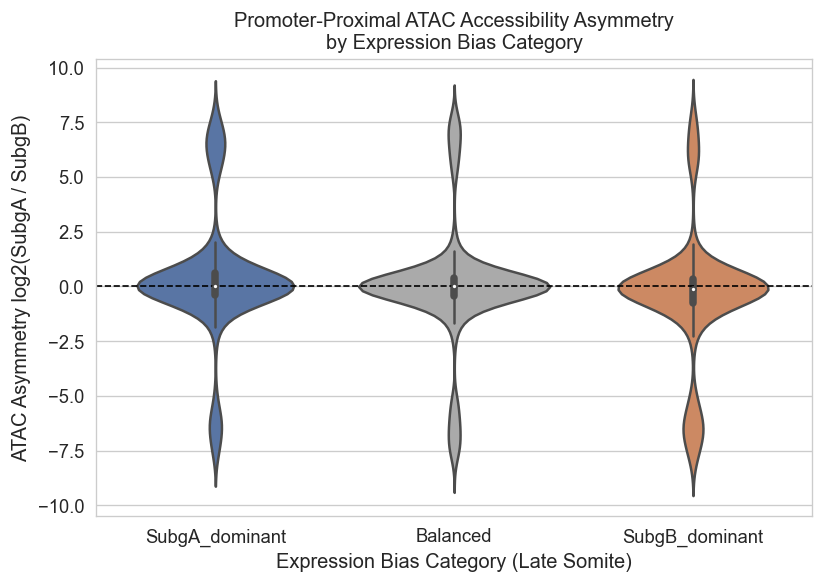

In [79]:
order    = ['SubgA_dominant', 'Balanced', 'SubgB_dominant']
palette  = {'SubgA_dominant': '#4C72B0', 'Balanced': '#aaaaaa', 'SubgB_dominant': '#DD8452'}

fig, ax = plt.subplots(figsize=(7, 5))
sns.violinplot(data=df_merged, x='bias_simple', y='atac_asymmetry',
               order=order, palette=palette, inner='box', ax=ax, cut=2)
ax.axhline(0, color='black', lw=1, linestyle='--')
ax.set_xlabel('Expression Bias Category (Late Somite)', fontsize=12)
ax.set_ylabel('ATAC Asymmetry log2(SubgA / SubgB)', fontsize=12)
ax.set_title('Promoter-Proximal ATAC Accessibility Asymmetry\nby Expression Bias Category', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'atac_asymmetry_violin_by_bias.png'), dpi=150)
plt.show()

### 7.3 ATAC Asymmetry by Bias Magnitude Category

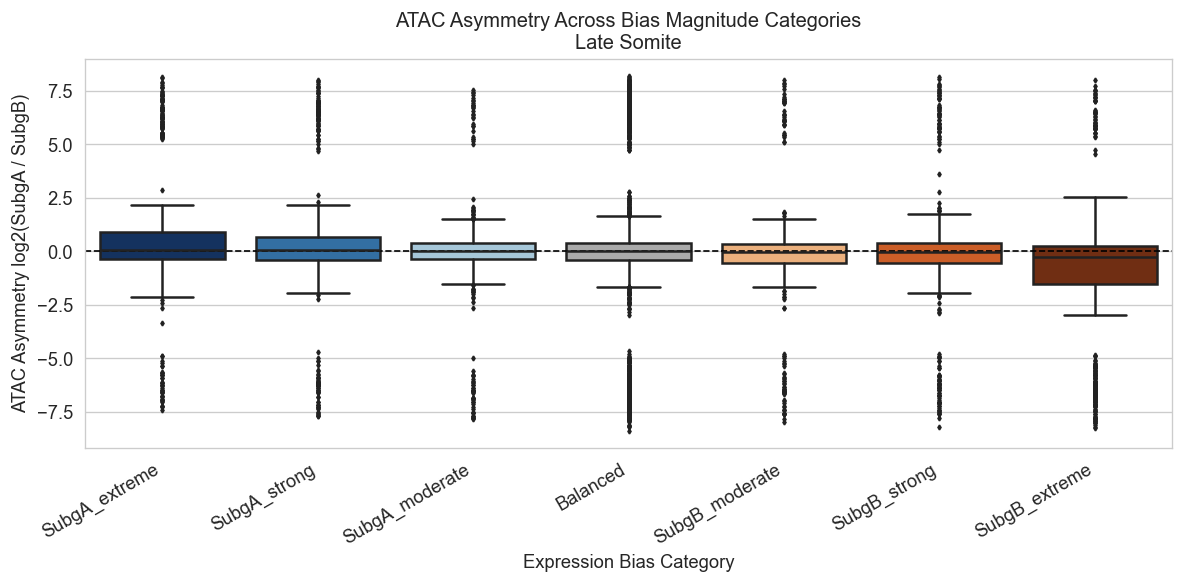

In [81]:
mag_order   = ['SubgA_extreme', 'SubgA_strong', 'SubgA_moderate',
                'Balanced',
                'SubgB_moderate', 'SubgB_strong', 'SubgB_extreme']
mag_palette = {
    'SubgA_extreme': '#08306b', 'SubgA_strong': '#2171b5', 'SubgA_moderate': '#9ecae1',
    'Balanced': '#aaaaaa',
    'SubgB_moderate': '#fdae6b', 'SubgB_strong': '#e6550d', 'SubgB_extreme': '#7f2704'
}

present_cats = [c for c in mag_order if c in df_merged['bias_lsom'].values]

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_merged[df_merged['bias_lsom'].isin(present_cats)],
            x='bias_lsom', y='atac_asymmetry',
            order=present_cats,
            palette={k: mag_palette[k] for k in present_cats},
            fliersize=2, ax=ax)
ax.axhline(0, color='black', lw=1, linestyle='--')
ax.set_xlabel('Expression Bias Category', fontsize=11)
ax.set_ylabel('ATAC Asymmetry log2(SubgA / SubgB)', fontsize=11)
ax.set_title('ATAC Asymmetry Across Bias Magnitude Categories\nLate Somite', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'atac_asymmetry_by_magnitude.png'), dpi=150)
plt.show()

### 7.4 Mean ATAC Fold Enrichment: SubgA vs SubgB by Bias Category

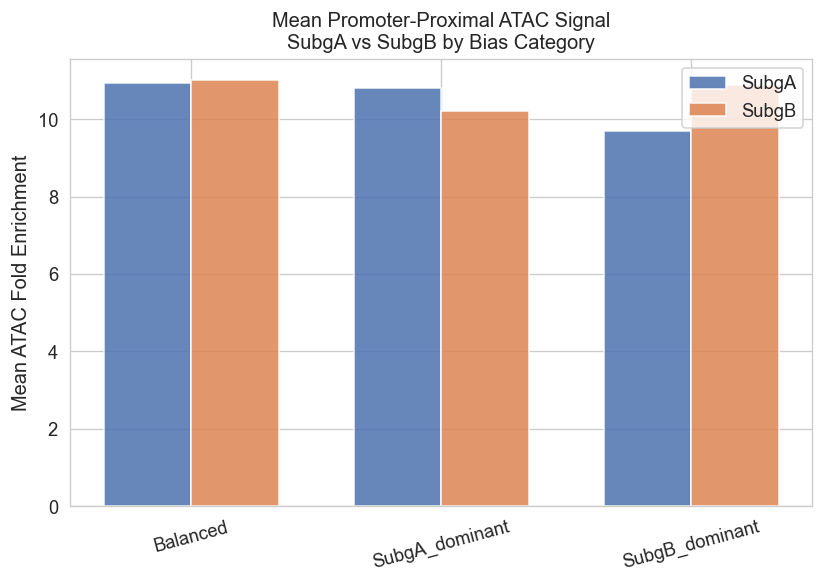

In [83]:
mean_enrich = df_merged.groupby('bias_simple')[['atac_fold_enrich_sgA', 'atac_fold_enrich_sgB']].mean()

x     = np.arange(len(mean_enrich))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width/2, mean_enrich['atac_fold_enrich_sgA'], width,
       label='SubgA', color='#4C72B0', alpha=0.85)
ax.bar(x + width/2, mean_enrich['atac_fold_enrich_sgB'], width,
       label='SubgB', color='#DD8452', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(mean_enrich.index, rotation=15)
ax.set_ylabel('Mean ATAC Fold Enrichment', fontsize=12)
ax.set_title('Mean Promoter-Proximal ATAC Signal\nSubgA vs SubgB by Bias Category', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'mean_atac_fold_enrich_by_bias.png'), dpi=150)
plt.show()

---
## 8. Save Outputs

In [85]:
# Full results table
out_full = os.path.join(OUT_DIR, 'ohnolog_atac_asymmetry_results.csv')
df_merged.to_csv(out_full, index=False)
print(f'Full results saved : {out_full}')

# Summary by bias category
out_summary = os.path.join(OUT_DIR, 'atac_asymmetry_summary_by_bias.csv')
df_merged.groupby('bias_lsom').agg(
    n=('atac_asymmetry', 'count'),
    mean_atac_asymmetry=('atac_asymmetry', 'mean'),
    median_atac_asymmetry=('atac_asymmetry', 'median'),
    mean_fold_enrich_sgA=('atac_fold_enrich_sgA', 'mean'),
    mean_fold_enrich_sgB=('atac_fold_enrich_sgB', 'mean'),
).round(4).to_csv(out_summary)
print(f'Summary saved      : {out_summary}')

print('\n✓ Analysis complete.')

Full results saved : /Users/rossgibson/Desktop/atac_analysis/ohnolog_atac_asymmetry_results.csv
Summary saved      : /Users/rossgibson/Desktop/atac_analysis/atac_asymmetry_summary_by_bias.csv

✓ Analysis complete.


In [ ]:
# Paste these cells into Section 9 of the notebook
# Replace the placeholder text under "Results from this section should be completed after running the analysis."

---

## MARKDOWN CELL — replace existing Section 9 content with this:

---
## 9. Interpretation of Results

### 9.1 Primary Finding: ATAC Accessibility Asymmetry Tracks Expression Bias at Genome-Wide Scale

The central result of this analysis is that promoter-proximal chromatin accessibility asymmetry is a
statistically significant correlate of expression bias across the full 7,497-pair ohnolog complement
at Late Somite stage (ρ = 0.115, p = 1.35×10⁻²³) and Pre-Hatch stage (ρ = 0.105, p = 5.60×10⁻²⁰).

This directly extends and recontextualises the non-significant ATAC finding from the MSc curated
analysis (q = 0.16–0.91 across all categories, n = 75). The genome-wide result strongly suggests that
the earlier non-significance reflected limited statistical power rather than a genuine absence of
accessibility divergence between subgenomes.

### 9.2 Directionality is Consistent with Subgenome Dominance

The direction of ATAC asymmetry is consistent with expression bias in both dominant categories:

| Bias Category   | n    | Mean ATAC Asymmetry | Interpretation                        |
|-----------------|------|---------------------|---------------------------------------|
| SubgA_dominant  | 1851 | +0.305              | SubgA copy more accessible            |
| Balanced        | 3677 | −0.015              | Near-symmetric accessibility          |
| SubgB_dominant  | 1969 | −0.444              | SubgB copy more accessible            |

SubgB-dominant pairs show a slightly stronger accessibility asymmetry signal (mean −0.444) than
SubgA-dominant pairs (mean +0.305), consistent with the pattern observed for histone marks in the
MSc analysis where SubgB dominance showed stronger and more statistically robust activation-mark
asymmetry than SubgA dominance.

All three pairwise comparisons between bias categories are highly significant by Mann-Whitney U test:
- SubgA_dominant vs SubgB_dominant: p = 1.61×10⁻¹⁸
- SubgA_dominant vs Balanced: p = 3.88×10⁻⁵
- SubgB_dominant vs Balanced: p = 1.27×10⁻¹⁰

### 9.3 Contextualisation Within the Multi-Omic Framework

The modest effect size (ρ ≈ 0.11) relative to the highly significant p-values reflects the large sample
size amplifying detection of a genuinely weak signal. This is biologically informative rather than
trivial — it suggests that accessibility asymmetry is a real but secondary contributor to regulatory
divergence, with histone modification differences (H3K27ac, H3K4me3) remaining the stronger and more
proximate correlate of active transcription bias.

A layered regulatory model emerges from combining the MSc findings with this genome-wide analysis:

1. **Chromatin accessibility asymmetry** is present genome-wide and directionally consistent with
   expression bias, but weak in magnitude. It likely reflects an early or permissive layer of
   regulatory divergence — establishing differential promoter competence across subgenomes.

2. **Histone modification asymmetry** (H3K27ac, H3K4me3) is a stronger, more proximate correlate of
   active expression bias, detectable at high effect size even in a curated subset of 75 pairs.
   H3K27ac in particular appears to mark the actively engaged promoter rather than the permissive
   state.

3. **Subgenome asymmetry** operates at multiple regulatory levels simultaneously, suggesting that
   post-WGD divergence in *C. carpio* involves reinforcing changes across the regulatory hierarchy
   rather than a single dominant mechanism.

This framework is consistent with findings in plant allopolyploids (Brassica napus) where
accessibility and histone mark changes co-occur but with different effect sizes and distributions,
and extends those plant-derived models into a vertebrate polyploid context.

### 9.4 Limitations and Caveats

**Coordinate precision**: TSS coordinates are derived from Ensembl annotations which use the same
WAG4.0 assembly as the narrowPeak file. However, without the original PADRE BED coordinates used in
the MSc analysis, promoter windows are TSS-centred (±2kb) rather than anchored to the nearest ATAC
summit. This is a less precise but scalable and reproducible definition. The modest correlation
observed may partly reflect this reduced precision — a PADRE-anchored analysis at genome-wide scale
would be expected to yield a stronger signal.

**Peak calling threshold**: Quantification relies on called peaks (fold enrichment from MACS2 output)
rather than continuous signal from bigWIG files. Loci with sub-threshold accessibility differences
are assigned zero, which compresses the asymmetry distribution toward zero and likely underestimates
the true correlation with expression bias.

**Single timepoint**: Accessibility data is available only for Late Somite. The Pre-Hatch Spearman
correlation uses Late Somite ATAC data against Pre-Hatch expression, which is a cross-stage
comparison. A dedicated Pre-Hatch ATAC dataset would be required for a clean within-stage analysis
at the second timepoint.

**Causal inference**: All results remain correlative. The direction and consistency of the findings
motivate but do not establish a causal relationship between promoter accessibility asymmetry and
differential subgenome expression.

### 9.5 Hypotheses Generated for Future Investigation

1. **PADRE-anchored re-quantification**: Applying the genome-wide intersection using PADRE BED
   coordinates rather than TSS-centred windows would likely yield stronger effect sizes and could
   be achieved given access to the full PADRE BED file.

2. **Accessibility magnitude thresholding**: Restricting the analysis to pairs where both copies
   have detectable ATAC signal (fold enrichment > 0 in both subgenomes) would remove the
   pseudocount-dominated zero pairs and potentially reveal a stronger signal in the accessible subset.

3. **Temporal dynamics**: A Pre-Hatch ATAC dataset would allow direct comparison of accessibility
   asymmetry trajectories with the observed shift toward balanced expression (49.1% → 53.4% balanced)
   between stages, testing whether accessibility changes precede or follow expression rebalancing.

4. **Subgenome-specific TF footprinting**: The Myc/Max (SubgB) and Pax-6 (SubgA) enrichment signals
   from the MSc could be extended by examining TF motif density within the accessible peaks
   identified here, linking accessibility asymmetry to specific regulatory programmes.

---



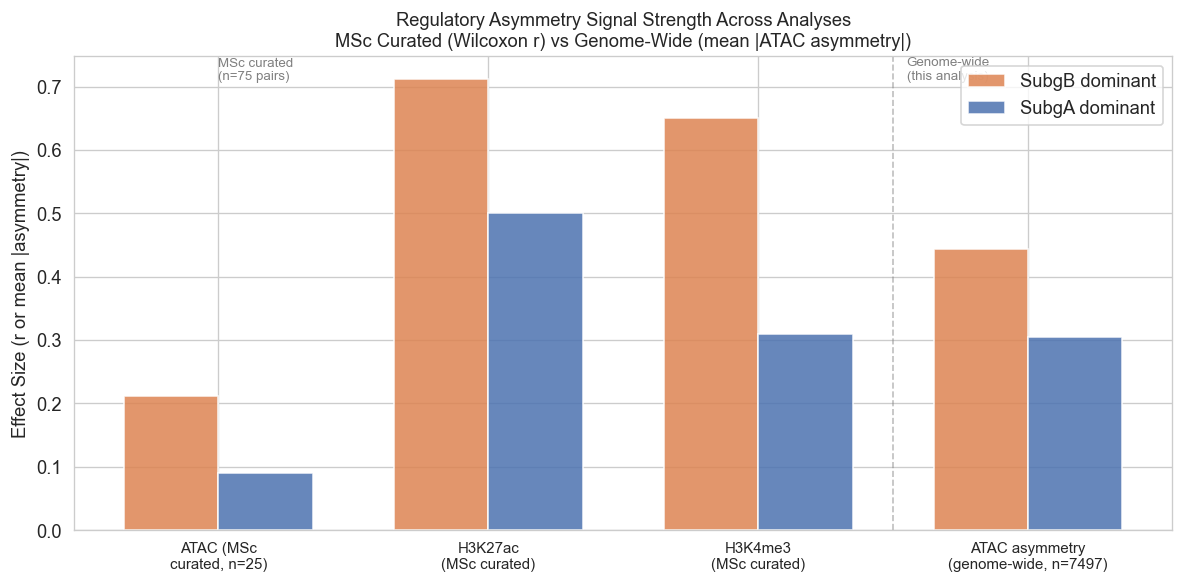

Figure saved.


In [91]:
## CODE CELL — add after the markdown above:

#python
# Summary figure: ATAC asymmetry effect size in context of MSc histone mark results
# Combines genome-wide ATAC result with curated histone mark effect sizes from MSc Table Sv

msc_effect_sizes = {
    'ATAC (MSc\ncurated, n=25)':   {'SubgB_dom': 0.211, 'SubgA_dom': 0.09},
    'H3K27ac\n(MSc curated)':      {'SubgB_dom': 0.712, 'SubgA_dom': 0.50},
    'H3K4me3\n(MSc curated)':      {'SubgB_dom': 0.650, 'SubgA_dom': 0.31},
    'ATAC asymmetry\n(genome-wide, n=7497)': {
        'SubgB_dom': abs(df_merged[df_merged['bias_simple']=='SubgB_dominant']['atac_asymmetry'].mean()),
        'SubgA_dom': abs(df_merged[df_merged['bias_simple']=='SubgA_dominant']['atac_asymmetry'].mean())
    }
}

labels   = list(msc_effect_sizes.keys())
subgb    = [msc_effect_sizes[l]['SubgB_dom'] for l in labels]
subga    = [msc_effect_sizes[l]['SubgA_dom'] for l in labels]

x     = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_b = ax.bar(x - width/2, subgb, width, label='SubgB dominant', color='#DD8452', alpha=0.85)
bars_a = ax.bar(x + width/2, subga, width, label='SubgA dominant', color='#4C72B0', alpha=0.85)

ax.set_ylabel('Effect Size (r or mean |asymmetry|)', fontsize=11)
ax.set_title('Regulatory Asymmetry Signal Strength Across Analyses\nMSc Curated (Wilcoxon r) vs Genome-Wide (mean |ATAC asymmetry|)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.legend()
ax.axvline(2.5, color='grey', linestyle='--', lw=1, alpha=0.5)
ax.text(2.55, ax.get_ylim()[1]*0.95, 'Genome-wide\n(this analysis)', fontsize=8, color='grey')
ax.text(0.0, ax.get_ylim()[1]*0.95, 'MSc curated\n(n=75 pairs)', fontsize=8, color='grey')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'regulatory_asymmetry_comparison.png'), dpi=150)
plt.show()

print("Figure saved.")
